# Data


In order to run the bellow cells, download Amazon datasets for electronics from https://amazon-reviews-2023.github.io/main.html and place them in the `/data` folder

In [1]:
import json
import gzip
import pandas as pd

In [3]:
with gzip.open("../../data/meta_Books.jsonl.gz") as f:
    first_line = json.loads(f.readline())

In [5]:
first_line

{'main_category': 'Books',
 'title': 'Chaucer',
 'subtitle': 'Hardcover – Import, January 1, 2004',
 'author': {'avatar': 'https://m.media-amazon.com/images/I/21Je2zja9pL._SY600_.jpg',
  'name': 'Peter Ackroyd',
  'about': ['Peter Ackroyd, (born 5 October 1949) is an English biographer, novelist and critic with a particular interest in the history and culture of London. For his novels about English history and culture and his biographies of, among others, William Blake, Charles Dickens, T. S. Eliot and Sir Thomas More, he won the Somerset Maugham Award and two Whitbread Awards. He is noted for the volume of work he has produced, the range of styles therein, his skill at assuming different voices and the depth of his research.',
   'He was elected a fellow of the Royal Society of Literature in 1984 and appointed a Commander of the Order of the British Empire in 2003.',
   'Bio from Wikipedia, the free encyclopedia.']},
 'average_rating': 4.5,
 'rating_number': 29,
 'features': [],
 'des

## Filter items that were published after 2022

In [14]:
def filter_out_data(data: dict) -> bool:
    filter = False
    if int(data['details']['Publisher'][-5:-1]) < 2022:
        filter = True
    
    return filter

In [17]:
with gzip.open("../../data/meta_Books.jsonl.gz", 'rt') as fp:
    with open("../../data/meta_Books_2022_2023.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("../../data/meta_Books_2022_2023_no_data.jsonl", 'a', encoding='utf-8') as fp_out_no_data:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    if not filter_out_data(data):
                        json.dump(data, fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                
                except:
                    json.dump(data, fp_out_no_data)
                    fp_out_no_data.write("\n")
                    fp_out_no_data.flush()
                
                i += 1
                if i % 10_000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

### Filter books with Main Category == `Books`

Exclude Kindle books

In [29]:
def filter_category(data: dict) -> bool:
    filter = False
    if len(data['categories']) < 2
        filter = True

    return filter

SyntaxError: expected ':' (1724799108.py, line 3)

In [30]:
with open("../../data/meta_Books_2022_2023.jsonl", 'rt') as fp:
    with open("../../data/meta_Books_2022_2023_Books.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("../../data/meta_Books_2022_2023_not_Books.jsonl", 'a', encoding='utf-8') as fp_out_no_data:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    if not filter_category(data):
                        json.dump(data, fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                
                except:
                    json.dump(data, fp_out_no_data)
                    fp_out_no_data.write("\n")
                    fp_out_no_data.flush()
                
                i += 1
                if i % 10_000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines


### Explore data distributions

In [38]:
df = pd.read_json("../../data/meta_Books_2022_2023_Books.jsonl", lines=True)

In [39]:
df

,main_category,title,subtitle,author,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Books,Heart of Silk and Shadows: A Fae Fantasy Roman...,"Paperback – May 29, 2022",{'avatar': 'https://m.media-amazon.com/images/...,4.4,481,[Stealing from a fae lord is a desperate plan…...,[],11.99,[{'large': 'https://m.media-amazon.com/images/...,[],Lisette Marshall (Author),"[Books, Science Fiction & Fantasy, Fantasy]","{'Publisher': 'Lisette Marshall (May 29, 2022)...",9083256898,NaN
1,Books,Girl Made of Glass,"Paperback – January 24, 2023",{'avatar': 'https://m.media-amazon.com/images/...,4.5,117,[If you think often about the past or battle w...,"[Review, “Reading this book was like reading m...",15.29,[{'large': 'https://m.media-amazon.com/images/...,[],Shel Leigh (Author),"[Books, Literature & Fiction, Poetry]",{'Publisher': 'Central Avenue Publishing (Janu...,1771682760,NaN
2,Books,The Melancholy Strumpet Master,"Paperback – February 19, 2023",{'avatar': 'https://m.media-amazon.com/images/...,4.6,14,"[""With a premise this original, I’d expect onl...","[Review, ★★★★★ ""The writing in The Melancholy ...",11.99,[{'large': 'https://m.media-amazon.com/images/...,[],Zeb Beck (Author),"[Books, Literature & Fiction, Humor & Satire]",{'Publisher': 'Independently published (Februa...,B0BW2GGCNZ,NaN
3,Books,Child Of The King A Journey of Hope Book 1: Ea...,"Paperback – December 1, 2022",{'avatar': 'https://m.media-amazon.com/images/...,4.8,51,[Encounter Jesus through the eyes of a first c...,[],8.99,[{'large': 'https://m.media-amazon.com/images/...,[],K. G. Ingram (Author),"[Books, Literature & Fiction]","{'Publisher': 'Self Publishing (December 1, 20...",B0BNTXTJFD,NaN
4,Books,The Grim Hunt: Crown of Madness,"Paperback – March 17, 2022",{'avatar': 'https://m.media-amazon.com/images/...,4.2,14,"[The Order of the Grim Hunt, a group dedicated...",[],14.99,[{'large': 'https://m.media-amazon.com/images/...,[],Ryan G. Beaty (Author),"[Books, Science Fiction & Fantasy, Fantasy]",{'Publisher': 'Independently published (March ...,B09VJTKRF1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177631,Books,The Collected Writings of Francis E. Dec Esquire,"Paperback – February 14, 2023",None,5.0,4,[The Collected Writings of Francis E. Dec Esqu...,[],13.97,[],[],"Francis Dec (Author), Nikolai Kaczynski (Author)","[Books, Literature & Fiction, Genre Fiction]","{'Publisher': 'Blurb (February 14, 2023)', 'La...",1034918648,NaN
177632,Books,World of Oil Derivatives: A Guide to Financial...,"Paperback – July 4, 2023",{'avatar': 'https://m.media-amazon.com/images/...,4.3,10,[In 'World of Oil Derivatives' Greg Newman bre...,[],None,[],[],Greg Newman (Author),"[Books, Business & Money, Economics]","{'Publisher': 'Amz Marketing Hub (July 4, 2023...",1916617883,NaN
177633,Books,Weekly Meal Planner: 52 Weeks of Meal Planning...,"Paperback – Notebook, May 19, 2022",{'avatar': 'https://m.media-amazon.com/images/...,4.5,2,"[With a simple, easy to use design, this meal ...",[],6.99,[],[],Better With Books (Author),"[Books, Cookbooks, Food & Wine, Cooking Methods]",{'Publisher': 'Independently published (May 19...,B0B289MMBR,NaN
177634,Books,"Fluidity: Love, Nature, and the unyielding hum...","Paperback – March 15, 2023",None,5.0,3,"[thakur bhullar's debut collection of poetry, ...",[],15.0,[],[],thakur bhullar (Author),"[Books, Literature & Fiction, Poetry]",{'Publisher': 'Independently published (March ...,B0C1J1LVR5,NaN


In [45]:
df['categories_middle'] = df['categories'].apply(lambda r: r[1] if len(r) > 1 else None)

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='categories_middle'>

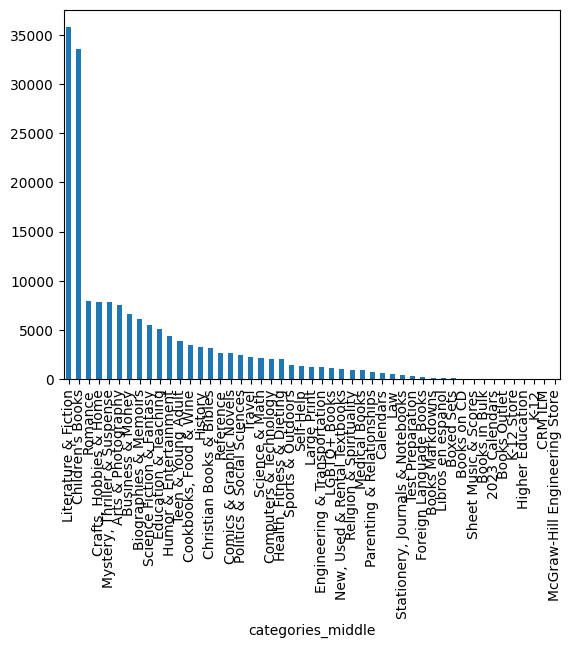

In [48]:
df['categories_middle'].value_counts().plot(kind="bar")

In [56]:
df[df['rating_number'] < 100]['rating_number'].value_counts()

rating_number
1     23476
2     14516
3     10851
4      8810
5      7413
      ...  
84      166
98      158
97      156
99      148
89      148
Name: count, Length: 99, dtype: int64

### Filter Books that have at least 10 ratings

In [57]:
df_ratings_10 = df[df['rating_number'] >= 10]

<Axes: xlabel='categories_middle'>

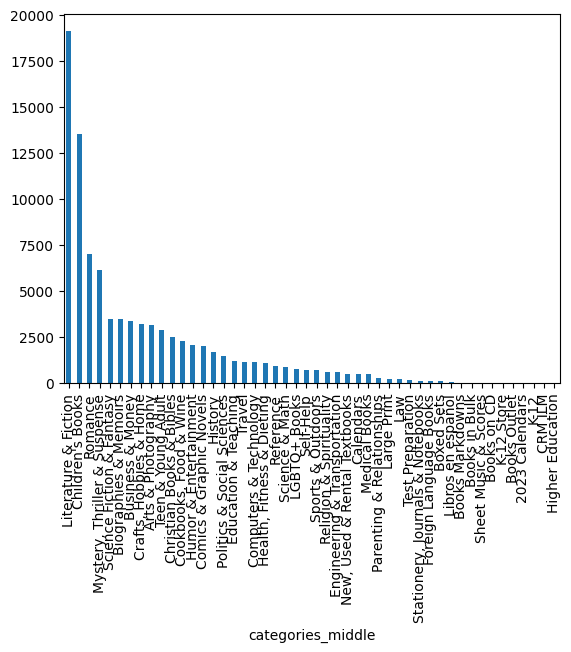

In [58]:
df_ratings_10['categories_middle'].value_counts().plot(kind="bar")

<Axes: ylabel='Frequency'>

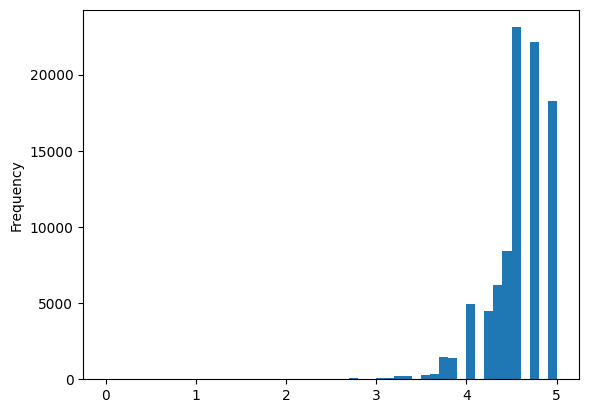

In [ ]:
df_ratings_10['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

### Sample 1000

In [60]:
df_sample_1000 = df_ratings_10.sample(n=1000, random_state=42)

In [61]:
len(df_sample_1000)

1000

<Axes: ylabel='Frequency'>

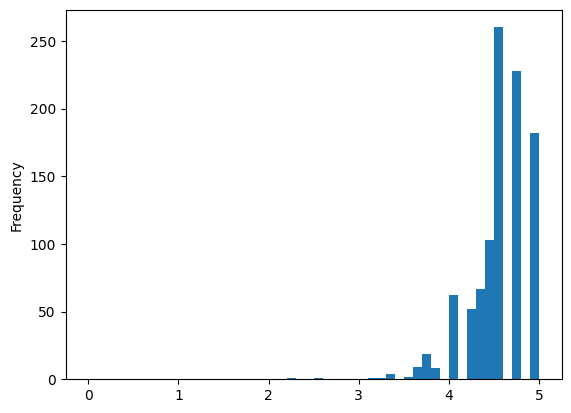

In [ ]:
df_sample_1000['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

In [68]:
df_ratings_10.to_json("../../data/meta_Books_2022_2023_with_category_ratings_10.jsonl", orient='records', lines=True)
df_sample_1000.to_json("../../data/meta_Books_2022_2023_with_category_ratings_10_sample_1000.jsonl", orient='records', lines=True)

### Extract reviews that match sample data

In [69]:
df_ratings_10 = pd.read_json("../../data/meta_Books_2022_2023_with_category_ratings_10.jsonl", lines=True)
df_sample_1000 = pd.read_json("../../data/meta_Books_2022_2023_with_category_ratings_10_sample_1000.jsonl", lines=True)

In [72]:
with gzip.open("../../data/Books.jsonl.gz", 'rt') as fp:
    with open('../../data/Books_2022_2023_with_category_ratings_10.jsonl', 'a') as fp_out:
        id_list = set(df_ratings_10['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i += 1
            if i % 100_000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P

In [73]:
with open('../../data/Books_2022_2023_with_category_ratings_10.jsonl', 'rt') as fp:
    with open('../../data/Books_2022_2023_with_category_ratings_10_sample_1000.jsonl', 'a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i += 1
            if i % 100_000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
